# Transformer Basics — Attention Is All You Need

## Goal
Understand the core mechanism behind BERT, GPT, and all modern LLMs.
Transformers replaced RNNs by processing all tokens simultaneously.

## Key Questions
- What is self-attention and how does it work?
- What are Query, Key, and Value?
- How does positional encoding preserve order?

## What We Build
Self-attention from scratch — the core of every transformer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

error uploading: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


## 1. Self-Attention — The Core Idea
Every token looks at every other token and decides how much to attend to it.

Three matrices are learned:
- Query (Q): "What am I looking for?"
- Key (K): "What do I contain?"
- Value (V): "What do I contribute?"

Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V

In [3]:
def softmax(x: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)


def self_attention(Q: np.ndarray, k: np.ndarray, V: np.ndarray) -> tuple:
    """
    Compute scaled dot-product self-attention.

    Args:
        Q: Query matrix (seq_len, d_k)
        K: Key matrix (seq_len, d_k)
        V: Value matrix (seq_len, d_v)

    Returns:
        output: Attended values (seq_len, d_v)
        weights: Attention weights (seq_len, seq_len)
    """
    d_k = Q.shape[-1]

    # Scaled dot product
    scores = np.dot(Q, K.T) / np.sqrt(d_k)

    # Softmax to get attention weights
    weights = softmax(scores)

    # Weighted to get attention weights
    output = np.dot(weights, V)

    return output, weights


# Test with a simple sentence
np.random.seed(42)
seq_len = 5   # "The cat sat on mat"
d_k = 8       # dimension of Q and K
d_v = 8       # dimension of V

Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, weights = self_attention(Q, K, V)

print(f"Query shape: {Q.shape}")
print(f"Key shape: {K.shape}")
print(f"Value shape: {V.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"Output shape: {output.shape}")
print(f"nAttention weights (each row sums to 1):")
print(weights.round(3))
print(f"\nRow sums: {weights.sum(axis=1).round(4)}")


Query shape: (5, 8)
Key shape: (5, 8)
Value shape: (5, 8)
Attention weights shape: (5, 5)
Output shape: (5, 8)
nAttention weights (each row sums to 1):
[[0.143 0.288 0.081 0.428 0.061]
 [0.185 0.023 0.291 0.113 0.388]
 [0.037 0.046 0.138 0.043 0.736]
 [0.341 0.139 0.09  0.318 0.112]
 [0.39  0.197 0.266 0.11  0.036]]

Row sums: [1. 1. 1. 1. 1.]


## 2. Visualize Attention Weights
Which tokens attend to which other tokens?

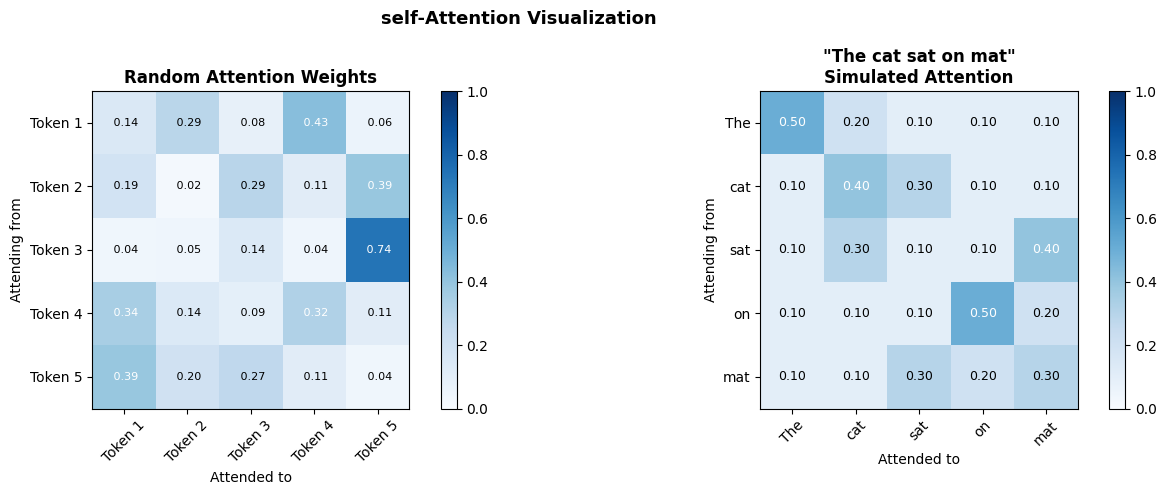

In [8]:
# Meaningful example — simulate attention for a real sentence
tokens = ["The", "cat", "sat", "on", "mat"]

# Simulate attention weights that make linguistic sense
# "cat" attends strongly to "sat" (subject-verb)
# "sat" attends to "mat" (verb-object)
attention_weights_demo = np.array([
    [0.5, 0.2, 0.1, 0.1, 0.1],  # The
    [0.1, 0.4, 0.3, 0.1, 0.1],  # cat
    [0.1, 0.3, 0.1, 0.1, 0.4],  # sat
    [0.1, 0.1, 0.1, 0.5, 0.2],  # on
    [0.1, 0.1, 0.3, 0.2, 0.3],  # mat
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Random attention weights
im1 = axes[0].imshow(weights, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels([f"Token {i+1}" for i in range(seq_len)], rotation=45)
axes[0].set_yticklabels([f"Token {i+1}" for i in range(seq_len)])
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f"{weights[i, j]: .2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if weights[i, j] > 0.3 else "black")
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("Random Attention Weights", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Attended to")
axes[0].set_ylabel("Attending from")

# Chart 2 - Meaningful attention weights
im2 = axes[1].imshow(attention_weights_demo, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(len(tokens)))
axes[1].set_yticks(range(len(tokens)))
axes[1].set_xticklabels(tokens, rotation=45)
axes[1].set_yticklabels(tokens)
for i in range (len(tokens)):
    for j in range(len(tokens)):
        axes[1].text(j, i, f"{attention_weights_demo[i, j]:.2f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if attention_weights_demo[i, j] > 0.3 else "black")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('"The cat sat on mat"\nSimulated Attention', fontsize=12, fontweight="bold")
axes[1].set_xlabel("Attended to")
axes[1].set_ylabel("Attending from")

plt.suptitle("self-Attention Visualization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("attention_visualization.png", dpi=300)
plt.show()

## 3. Positional Encoding
Transformers process all tokens simultaneously — they lose order information.
Positional encoding adds position information to each token embedding.

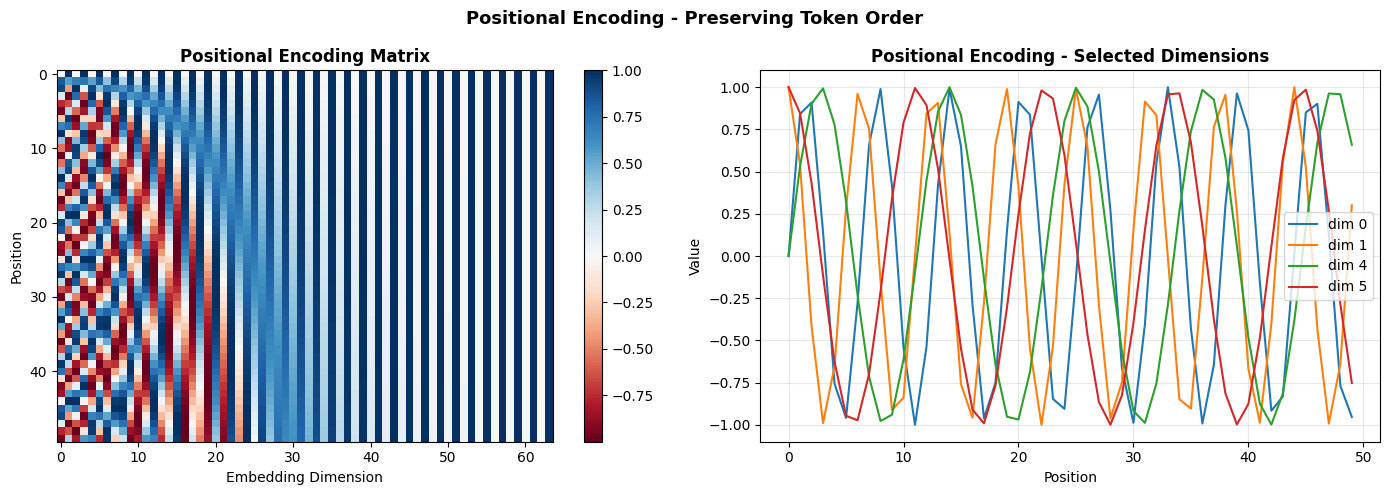

In [9]:
def positional_encoding(seq_len: int, d_model: int) -> np.ndarray:
    """
    Compute sinusoidal positional encoding.
    Even dimensions use sine, odd dimensions use cosine.
    """
    PE = np.zeros((seq_len, d_model))

    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            PE[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                PE[pos, i+1] = np.cos(pos / 10000 ** (i / d_model))

    return PE

# Compute positional encoding
seq_len = 50
d_model = 64
PE = positional_encoding(seq_len, d_model)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(PE, cmap="RdBu", aspect="auto", interpolation="nearest")
axes[0].set_title("Positional Encoding Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position")
plt.colorbar(im, ax=axes[0])

# Show first few dimensions
for dim in [0, 1, 4, 5]:
    axes[1].plot(PE[:, dim], label=f"dim {dim}", linewidth=1.5)
axes[1].set_title("Positional Encoding - Selected Dimensions", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Positional Encoding - Preserving Token Order", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=300)
plt.show()

## 4. Key Observations

## Self-Attention vs RNN

| | RNN | Transformer |
|--|-----|------------|
| Processing | Sequential | Parallel |
| Memory | Hidden state | Attention over all tokens |
| Long-range | Vanishes | Direct connection |
| Speed | Slow | Fast |

## How Self-Attention Works
1. Each token creates Q, K, V vectors
2. Q of each token is compared with K of all tokens
3. Scores are normalized with softmax
4. Each token gets a weighted sum of all V vectors

## Positional Encoding
Without it, "cat sat on mat" = "mat on sat cat" — same tokens, different order.
Sinusoidal encoding gives each position a unique fingerprint.
Lower dimensions change fast, higher dimensions change slow — like a clock.

## Key Insight
The transformer's power comes from attention's global receptive field.
Every token can directly attend to every other token — no vanishing gradient across positions.
This is why BERT understands "bank" differently in "river bank" vs "bank account."

## Conclusion
We built every component of the transformer from scratch:
- Perceptron → Neural Network → Backpropagation → CNN → RNN → Transformer
Each solved the limitations of the previous one.